<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/Puzzle_A_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import heapq
import numpy as np

class PuzzleSolver:
    def __init__(self):
        self.goal = (1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 0)
        self.moves = {
            0: [1, 3],
            1: [0, 2, 4],
            2: [1, 5],
            3: [0, 4, 6],
            4: [1, 3, 5, 7],
            5: [2, 4, 8],
            6: [3, 7, 9],
            7: [4, 6, 8, 10],
            8: [5, 7, 11],
            9: [6, 10],
            10: [7, 9, 11],
            11: [8, 10]
        }

    def manhattan_distance(self, state):
        distance = 0
        for i, num in enumerate(state):
            if num != 0:
                goal_row, goal_col = divmod(num - 1, 3)
                current_row, current_col = divmod(i, 3)
                distance += abs(goal_row - current_row) + abs(goal_col - current_col)
        return distance

    def get_neighbors(self, state):
        empty_index = state.index(0)
        neighbors = []
        for move in self.moves[empty_index]:
            new_state = list(state)
            new_state[empty_index], new_state[move] = new_state[move], new_state[empty_index]
            neighbors.append(tuple(new_state))
        return neighbors

    def solve(self, start):
        open_list = []
        heapq.heappush(open_list, (0 + self.manhattan_distance(start), 0, start, []))
        closed_set = set()
        g_score = {start: 0}

        while open_list:
            _, g, current, path = heapq.heappop(open_list)

            if current == self.goal:
                return path + [current]

            if current in closed_set:
                continue

            closed_set.add(current)

            for neighbor in self.get_neighbors(current):
                new_g = g + 1
                if neighbor not in g_score or new_g < g_score[neighbor]:
                    g_score[neighbor] = new_g
                    f_score = new_g + self.manhattan_distance(neighbor)
                    heapq.heappush(open_list, (f_score, new_g, neighbor, path + [current]))

        return None

    def print_puzzle(self, state):
        for i in range(0, 12, 3):
            print(state[i:i+3])
        print()

# Ejemplo de uso
if __name__ == "__main__":
    solver = PuzzleSolver()

    # Estado inicial de ejemplo (personalizable)
    # Para probar con un estado inicial diferente
    start_state = (1, 2, 3, 4, 5, 6, 7, 8, 0, 9, 10, 11)

    print("Estado inicial:")
    solver.print_puzzle(start_state)

    solution = solver.solve(start_state)

    if solution:
        print(f"¡Solución encontrada en {len(solution)-1} movimientos!")
        print("\nPasos de la solución:")
        for step, state in enumerate(solution):
            print(f"Paso {step}:")
            solver.print_puzzle(state)
    else:
        print("No se encontró solución")

Estado inicial:
(1, 2, 3)
(4, 5, 6)
(7, 8, 0)
(9, 10, 11)

¡Solución encontrada en 13 movimientos!

Pasos de la solución:
Paso 0:
(1, 2, 3)
(4, 5, 6)
(7, 8, 0)
(9, 10, 11)

Paso 1:
(1, 2, 3)
(4, 5, 6)
(7, 8, 11)
(9, 10, 0)

Paso 2:
(1, 2, 3)
(4, 5, 6)
(7, 8, 11)
(9, 0, 10)

Paso 3:
(1, 2, 3)
(4, 5, 6)
(7, 8, 11)
(0, 9, 10)

Paso 4:
(1, 2, 3)
(4, 5, 6)
(0, 8, 11)
(7, 9, 10)

Paso 5:
(1, 2, 3)
(4, 5, 6)
(8, 0, 11)
(7, 9, 10)

Paso 6:
(1, 2, 3)
(4, 5, 6)
(8, 9, 11)
(7, 0, 10)

Paso 7:
(1, 2, 3)
(4, 5, 6)
(8, 9, 11)
(7, 10, 0)

Paso 8:
(1, 2, 3)
(4, 5, 6)
(8, 9, 0)
(7, 10, 11)

Paso 9:
(1, 2, 3)
(4, 5, 6)
(8, 0, 9)
(7, 10, 11)

Paso 10:
(1, 2, 3)
(4, 5, 6)
(0, 8, 9)
(7, 10, 11)

Paso 11:
(1, 2, 3)
(4, 5, 6)
(7, 8, 9)
(0, 10, 11)

Paso 12:
(1, 2, 3)
(4, 5, 6)
(7, 8, 9)
(10, 0, 11)

Paso 13:
(1, 2, 3)
(4, 5, 6)
(7, 8, 9)
(10, 11, 0)



=== RESOLVEDOR DE PUZZLE 4x3 CON A* ===
Resolviendo puzzle...

Estado inicial:


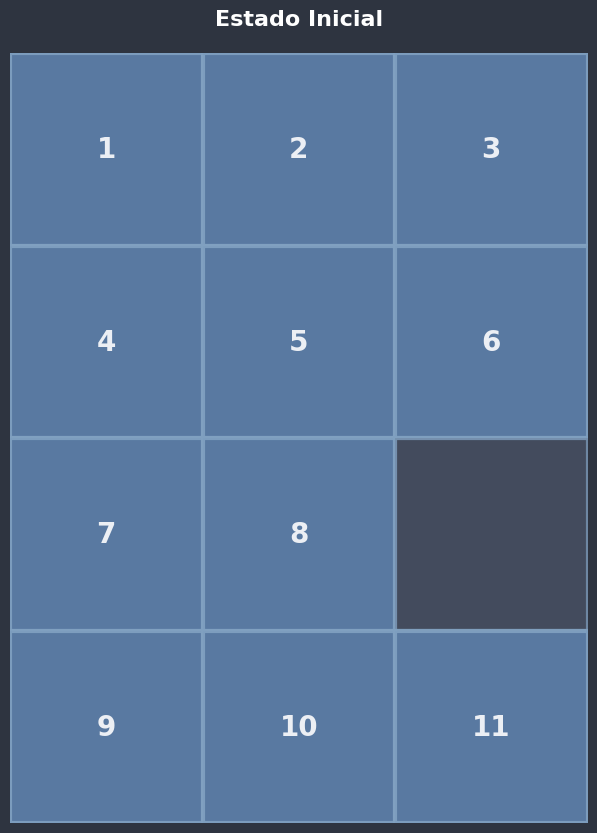

¡Solución encontrada en 13 movimientos!


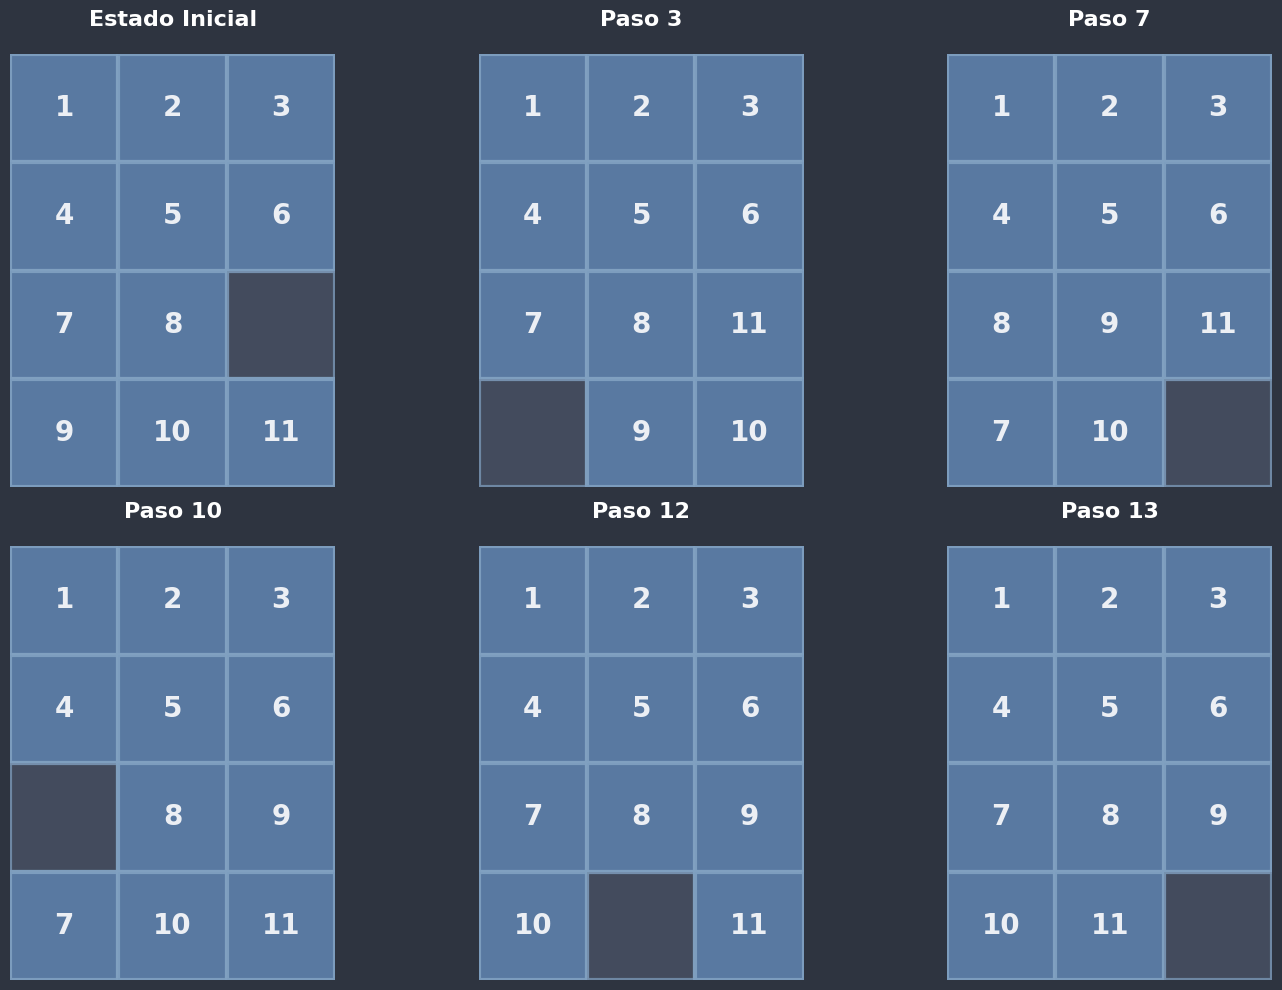


Generando animación...



=== RESUMEN ===
Movimientos totales: 13
Estado inicial: (1, 2, 3, 4, 5, 6, 7, 8, 0, 9, 10, 11)
Estado final: (1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 0)


In [5]:
import heapq
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import matplotlib.animation as animation
from IPython.display import HTML, display

class PuzzleSolver:
    def __init__(self):
        self.goal = (1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 0)
        self.moves = {
            0: [1, 3],
            1: [0, 2, 4],
            2: [1, 5],
            3: [0, 4, 6],
            4: [1, 3, 5, 7],
            5: [2, 4, 8],
            6: [3, 7, 9],
            7: [4, 6, 8, 10],
            8: [5, 7, 11],
            9: [6, 10],
            10: [7, 9, 11],
            11: [8, 10]
        }

    def manhattan_distance(self, state):
        distance = 0
        for i, num in enumerate(state):
            if num != 0:
                goal_row, goal_col = divmod(num - 1, 3)
                current_row, current_col = divmod(i, 3)
                distance += abs(goal_row - current_row) + abs(goal_col - current_col)
        return distance

    def get_neighbors(self, state):
        empty_index = state.index(0)
        neighbors = []
        for move in self.moves[empty_index]:
            new_state = list(state)
            new_state[empty_index], new_state[move] = new_state[move], new_state[empty_index]
            neighbors.append(tuple(new_state))
        return neighbors

    def solve(self, start):
        open_list = []
        heapq.heappush(open_list, (0 + self.manhattan_distance(start), 0, start, []))
        closed_set = set()
        g_score = {start: 0}

        while open_list:
            _, g, current, path = heapq.heappop(open_list)

            if current == self.goal:
                return path + [current]

            if current in closed_set:
                continue

            closed_set.add(current)

            for neighbor in self.get_neighbors(current):
                new_g = g + 1
                if neighbor not in g_score or new_g < g_score[neighbor]:
                    g_score[neighbor] = new_g
                    f_score = new_g + self.manhattan_distance(neighbor)
                    heapq.heappush(open_list, (f_score, new_g, neighbor, path + [current]))

        return None

    def visualize_puzzle(self, state, title="", ax=None):
        if ax is None:
            fig, ax = plt.subplots(figsize=(8, 10))
        else:
            fig = ax.figure # Get the figure from the provided axes

        # Configurar el fondo
        ax.set_facecolor('#2E3440')
        fig.patch.set_facecolor('#2E3440')

        # Colores para las piezas (tema nord)
        colors = {
            'background': '#2E3440',
            'tile': '#5E81AC',
            'empty': '#4C566A',
            'text': '#ECEFF4',
            'border': '#81A1C1'
        }

        # Dibujar el tablero
        for i in range(4):
            for j in range(3):
                index = i * 3 + j
                value = state[index]

                # Coordenadas
                x = j
                y = 3 - i  # Invertir para que la fila 0 esté arriba

                if value == 0:
                    # Espacio vacío
                    rect = Rectangle((x, y), 1, 1,
                                   facecolor=colors['empty'],
                                   edgecolor=colors['border'],
                                   linewidth=3,
                                   alpha=0.7)
                    ax.add_patch(rect)
                else:
                    # Pieza con número
                    rect = Rectangle((x, y), 1, 1,
                                   facecolor=colors['tile'],
                                   edgecolor=colors['border'],
                                   linewidth=3,
                                   alpha=0.9)
                    ax.add_patch(rect)

                    # Texto del número
                    ax.text(x + 0.5, y + 0.5, str(value),
                           fontsize=20, fontweight='bold',
                           color=colors['text'],
                           ha='center', va='center')

        # Configurar el gráfico
        ax.set_xlim(0, 3)
        ax.set_ylim(0, 4)
        ax.set_aspect('equal')
        ax.axis('off')
        ax.set_title(title, fontsize=16, color='white', fontweight='bold', pad=20)

        return ax

    def create_animation(self, solution, filename="puzzle_solution.gif"):
        if not solution:
            print("No hay solución para animar")
            return

        fig, ax = plt.subplots(figsize=(8, 10))
        fig.patch.set_facecolor('#2E3440')

        def animate(frame):
            ax.clear()
            state = solution[frame]
            title = f"Paso {frame}/{len(solution)-1}"
            self.visualize_puzzle(state, title, ax)
            return []

        # Crear animación
        anim = animation.FuncAnimation(fig, animate, frames=len(solution),
                                     interval=800, blit=False, repeat=False)

        # Guardar como GIF
        anim.save(filename, writer='pillow', fps=2)
        plt.close()

        # Mostrar en Colab
        display(HTML(f'<img src="{filename}">'))

        return anim

    def print_solution_steps(self, solution):
        if not solution:
            print("No se encontró solución")
            return

        print(f"¡Solución encontrada en {len(solution)-1} movimientos!")

        # Crear figura con subplots para mostrar algunos pasos clave
        key_steps = self._get_key_steps(solution)

        fig, axes = plt.subplots(2, 3, figsize=(15, 10))
        fig.patch.set_facecolor('#2E3440')

        for idx, step_idx in enumerate(key_steps):
            ax = axes[idx // 3, idx % 3]
            state = solution[step_idx]
            title = f"Paso {step_idx}" if step_idx > 0 else "Estado Inicial"
            self.visualize_puzzle(state, title, ax)

        # Ocultar ejes vacíos si hay menos de 6 pasos
        for idx in range(len(key_steps), 6):
            axes[idx // 3, idx % 3].axis('off')

        plt.tight_layout()
        plt.show()

    def _get_key_steps(self, solution):
        """Selecciona pasos clave para mostrar"""
        total_steps = len(solution)
        if total_steps <= 6:
            return list(range(total_steps))
        else:
            # Mostrar primero, último y algunos intermedios
            return [0,
                   total_steps // 4,
                   total_steps // 2,
                   3 * total_steps // 4,
                   total_steps - 2,
                   total_steps - 1]

# Función para generar un estado inicial válido
def generate_solvable_state():
    """Genera un estado inicial que se sabe es solucionable"""
    # Un estado que está a pocos movimientos de la solución
    base = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 0]
    # Hacer algunos intercambios válidos
    swaps = [(10, 11), (8, 9), (6, 7)]
    for i, j in swaps:
        base[i], base[j] = base[j], base[i]
    return tuple(base)

# Ejemplo de uso mejorado
if __name__ == "__main__":
    solver = PuzzleSolver()

    # Estados de ejemplo o generar uno aleatorio
    print("=== RESOLVEDOR DE PUZZLE 4x3 CON A* ===")

    # Opción 1: Estado predefinido
    start_state = (1, 2, 3, 4, 5, 6, 7, 8, 0, 9, 10, 11)

    # Opción 2: Estado generado
    # start_state = generate_solvable_state()

    print("Resolviendo puzzle...")

    # Mostrar estado inicial
    print("\nEstado inicial:")
    solver.visualize_puzzle(start_state, "Estado Inicial")
    plt.show()

    # Resolver
    solution = solver.solve(start_state)

    if solution:
        # Mostrar pasos clave
        solver.print_solution_steps(solution)

        # Crear y mostrar animación
        print("\nGenerando animación...")
        solver.create_animation(solution, "puzzle_solution.gif")

        # Mostrar información adicional
        print(f"\n=== RESUMEN ===")
        print(f"Movimientos totales: {len(solution)-1}")
        print(f"Estado inicial: {start_state}")
        print(f"Estado final: {solution[-1]}")

    else:
        print("No se encontró solución para el estado inicial dado")